# 04 — ResNet18 : comparaison Option A vs Option B

## Objectif
Comparer **deux stratégies de gestion du déséquilibre des classes** pour la classification binaire :

- **Option A** : `CrossEntropyLoss(weight=class_weights)`
- **Option B** : `WeightedRandomSampler`

Le notebook **importe tout depuis `src/`** :
- dataset
- transforms
- split
- loaders
- modèle ResNet18
- engine d'entraînement
- métriques

## Bonne pratique
Ce notebook ne redéfinit ni le dataset ni le modèle.  
Il sert uniquement à **orchestrer les expériences** et à **analyser les résultats**.


## 1) Rendre `src/` importable
Cette cellule permet au notebook de retrouver le package `pinkcc_ct_seg` même s'il est exécuté depuis `notebooks/`.


In [5]:
from pathlib import Path
import sys
import sys
import os

sys.path.append("..")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SRC exists =", SRC_DIR.exists())


PROJECT_ROOT = C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification
SRC exists = True


## 2) Imports du projet


In [6]:

from collections import Counter
from copy import deepcopy

import torch
from torch import nn
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt

from pinkcc_ct_seg.data.dataset import BrainMRIDataset
from pinkcc_ct_seg.data.transforms import get_train_transforms, get_eval_transforms
from pinkcc_ct_seg.data.split import make_train_val_split
from pinkcc_ct_seg.data.loaders import make_loaders, make_weighted_sampler

from pinkcc_ct_seg.models.resnet18 import build_resnet18, freeze_backbone, unfreeze_layer4_and_fc
from pinkcc_ct_seg.training.engine import train_one_epoch, validate_one_epoch
from pinkcc_ct_seg.training.utils import set_seed, get_device, save_checkpoint
from pinkcc_ct_seg.evaluation.metrics import compute_metrics

print("torch version:", torch.__version__)


torch version: 2.10.0+cpu


## 3) Configuration générale


In [7]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS_HEAD = 3
EPOCHS_FT = 3

set_seed(SEED)
device = get_device()

DATA_DIR = PROJECT_ROOT / "data/raw/brain_mri/Training"
TEST_DIR = PROJECT_ROOT / "data/raw/brain_mri/Testing"

print("device =", device)
print("DATA_DIR exists =", DATA_DIR.exists())
print("TEST_DIR exists =", TEST_DIR.exists())


device = cpu
DATA_DIR exists = True
TEST_DIR exists = True


## 4) Dataset, split train/val et test


In [8]:
train_tfms = get_train_transforms(img_size=IMG_SIZE)
eval_tfms = get_eval_transforms(img_size=IMG_SIZE)

full_train_ds = BrainMRIDataset(DATA_DIR, transform=train_tfms)
labels = [full_train_ds.samples[i][1] for i in range(len(full_train_ds))]

print("Nb images train total:", len(full_train_ds))
print("Distribution globale:", Counter(labels))

train_idx, val_idx = make_train_val_split(labels, val_size=0.2, random_state=SEED)

train_ds = Subset(full_train_ds, train_idx)

full_eval_ds = BrainMRIDataset(DATA_DIR, transform=eval_tfms)
val_ds = Subset(full_eval_ds, val_idx)

test_ds = BrainMRIDataset(TEST_DIR, transform=eval_tfms)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))


Nb images train total: 2870
Distribution globale: Counter({1: 2475, 0: 395})
Train size: 2296
Val size: 574
Test size: 394


## 5) Utilitaires d'expérience
Le modèle est entraîné en 2 phases :
1. tête `fc` seulement
2. fine-tuning léger de `layer4 + fc`


In [9]:
def make_class_weights_from_train_idx(dataset, train_idx, device):
    train_labels = [dataset.samples[i][1] for i in train_idx]
    c = Counter(train_labels)
    w0 = 1.0 / c[0]
    w1 = 1.0 / c[1]
    return torch.tensor([w0, w1], dtype=torch.float32, device=device), c


def evaluate_model(model, loader, criterion, device):
    stats = validate_one_epoch(model, loader, criterion, device)
    metrics = compute_metrics(stats["targets"], stats["preds"])
    return stats, metrics


def run_experiment(option_name: str, weighted_sampler: bool = False, weighted_loss: bool = False):
    print(f"\n===== {option_name} =====")

    model = build_resnet18(num_classes=2, pretrained=True)
    model = freeze_backbone(model)
    model = model.to(device)

    class_weights, train_counter = make_class_weights_from_train_idx(full_train_ds, train_idx, device)

    if weighted_loss:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    if weighted_sampler:
        sampler = make_weighted_sampler(train_ds)
        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
        )
    else:
        train_loader, _ = make_loaders(
            train_ds,
            val_ds,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            weighted=False,
            pin_memory=(device.type == "cuda"),
        )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(1, EPOCHS_HEAD + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va = validate_one_epoch(model, val_loader, criterion, device)
        metrics = compute_metrics(va["targets"], va["preds"])

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])

        print(f"[HEAD] Epoch {epoch}/{EPOCHS_HEAD} | "
              f"train loss {tr['loss']:.4f} acc {tr['acc']:.3f} | "
              f"val loss {va['loss']:.4f} acc {va['acc']:.3f} f1 {metrics['f1']:.3f}")

        if metrics["f1"] > best_val_f1:
            best_val_f1 = metrics["f1"]
            best_state = deepcopy(model.state_dict())

    model = unfreeze_layer4_and_fc(model)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    for epoch in range(1, EPOCHS_FT + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va = validate_one_epoch(model, val_loader, criterion, device)
        metrics = compute_metrics(va["targets"], va["preds"])

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])

        print(f"[FT]   Epoch {epoch}/{EPOCHS_FT} | "
              f"train loss {tr['loss']:.4f} acc {tr['acc']:.3f} | "
              f"val loss {va['loss']:.4f} acc {va['acc']:.3f} f1 {metrics['f1']:.3f}")

        if metrics["f1"] > best_val_f1:
            best_val_f1 = metrics["f1"]
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    val_stats, val_metrics = evaluate_model(model, val_loader, criterion, device)
    test_stats, test_metrics = evaluate_model(model, test_loader, criterion, device)

    return {
        "model": model,
        "history": history,
        "criterion": criterion,
        "val_stats": val_stats,
        "val_metrics": val_metrics,
        "test_stats": test_stats,
        "test_metrics": test_metrics,
        "class_weights": class_weights.detach().cpu().tolist(),
        "train_counter": train_counter,
    }


## 6) Option A — Loss pondérée
On garde un `DataLoader` classique, mais on pondère la `CrossEntropyLoss` avec des poids inverses aux fréquences des classes.


In [10]:
res_A = run_experiment(
    option_name="Option A - Weighted Loss",
    weighted_sampler=False,
    weighted_loss=True,
)



===== Option A - Weighted Loss =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Ange/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 50.9MB/s]


✅ ResNet18 chargé avec poids préentraînés.


[HEAD] Epoch 1/3 | train loss 0.4712 acc 0.806 | val loss 0.3112 acc 0.897 f1 0.937


[HEAD] Epoch 2/3 | train loss 0.2662 acc 0.919 | val loss 0.2295 acc 0.918 f1 0.951


[HEAD] Epoch 3/3 | train loss 0.2196 acc 0.935 | val loss 0.2045 acc 0.941 f1 0.965


[FT]   Epoch 1/3 | train loss 0.1297 acc 0.953 | val loss 0.0989 acc 0.958 f1 0.975


[FT]   Epoch 2/3 | train loss 0.0647 acc 0.978 | val loss 0.0975 acc 0.962 f1 0.977


[FT]   Epoch 3/3 | train loss 0.0271 acc 0.990 | val loss 0.0449 acc 0.983 f1 0.990


## 7) Option B — WeightedRandomSampler
On garde une loss classique, mais on équilibre mieux les batches via un `WeightedRandomSampler`.


In [11]:
res_B = run_experiment(
    option_name="Option B - Weighted Sampler",
    weighted_sampler=True,
    weighted_loss=False,
)



===== Option B - Weighted Sampler =====
✅ ResNet18 chargé avec poids préentraînés.


[HEAD] Epoch 1/3 | train loss 0.4293 acc 0.810 | val loss 0.2863 acc 0.920 f1 0.952


[HEAD] Epoch 2/3 | train loss 0.2578 acc 0.917 | val loss 0.3025 acc 0.889 f1 0.931


[HEAD] Epoch 3/3 | train loss 0.2133 acc 0.937 | val loss 0.1960 acc 0.941 f1 0.965


[FT]   Epoch 1/3 | train loss 0.1053 acc 0.970 | val loss 0.0666 acc 0.977 f1 0.987


[FT]   Epoch 2/3 | train loss 0.0447 acc 0.987 | val loss 0.0301 acc 0.993 f1 0.996


[FT]   Epoch 3/3 | train loss 0.0222 acc 0.994 | val loss 0.0325 acc 0.990 f1 0.994


## 8) Comparaison des résultats


In [12]:
def summarize_result(name, res):
    vm = res["val_metrics"]
    tm = res["test_metrics"]
    return {
        "name": name,
        "val_acc": vm["accuracy"],
        "val_precision": vm["precision"],
        "val_recall": vm["recall"],
        "val_f1": vm["f1"],
        "test_acc": tm["accuracy"],
        "test_precision": tm["precision"],
        "test_recall": tm["recall"],
        "test_f1": tm["f1"],
    }

summary_A = summarize_result("Option A", res_A)
summary_B = summarize_result("Option B", res_B)

summary_A, summary_B


({'name': 'Option A',
  'val_acc': 0.9825783972125436,
  'val_precision': 1.0,
  'val_recall': 0.9797979797979798,
  'val_f1': 0.9897959183673469,
  'test_acc': 0.8223350253807107,
  'test_precision': 1.0,
  'test_recall': 0.7577854671280276,
  'test_f1': 0.8622047244094488},
 {'name': 'Option B',
  'val_acc': 0.9930313588850174,
  'val_precision': 1.0,
  'val_recall': 0.9919191919191919,
  'val_f1': 0.9959432048681541,
  'test_acc': 0.8375634517766497,
  'test_precision': 1.0,
  'test_recall': 0.7785467128027682,
  'test_f1': 0.8754863813229572})

In [13]:
print("=== Option A ===")
for k, v in summary_A.items():
    print(f"{k}: {v}")

print("\n=== Option B ===")
for k, v in summary_B.items():
    print(f"{k}: {v}")


=== Option A ===
name: Option A
val_acc: 0.9825783972125436
val_precision: 1.0
val_recall: 0.9797979797979798
val_f1: 0.9897959183673469
test_acc: 0.8223350253807107
test_precision: 1.0
test_recall: 0.7577854671280276
test_f1: 0.8622047244094488

=== Option B ===
name: Option B
val_acc: 0.9930313588850174
val_precision: 1.0
val_recall: 0.9919191919191919
val_f1: 0.9959432048681541
test_acc: 0.8375634517766497
test_precision: 1.0
test_recall: 0.7785467128027682
test_f1: 0.8754863813229572


## 9) Courbes de loss / accuracy


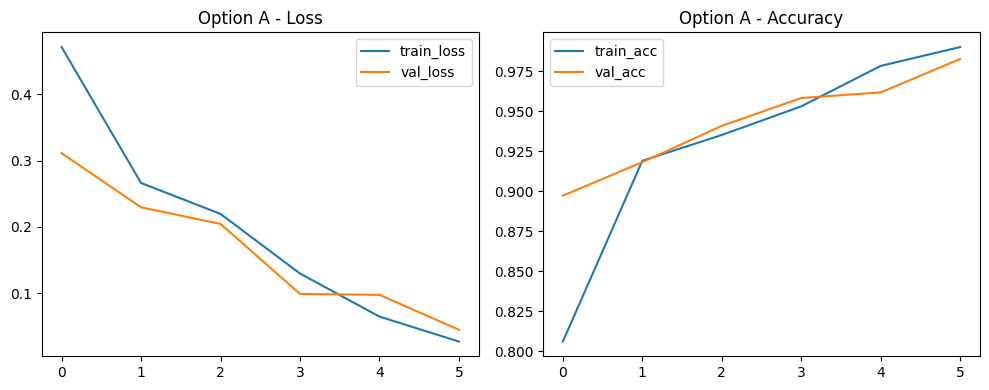

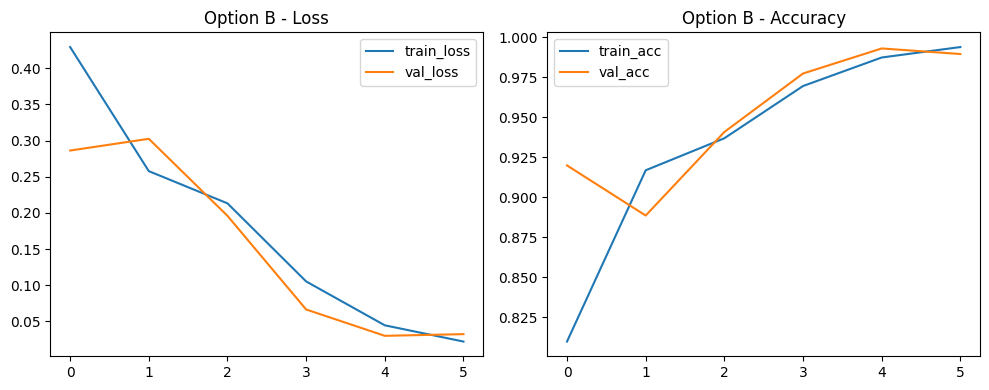

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(res_A["history"], "Option A")
plot_history(res_B["history"], "Option B")


## 10) Matrices de confusion (test)


In [15]:
print("=== Option A - rapport test ===")
print(res_A["test_metrics"]["classification_report"])
print("Confusion matrix A:\n", res_A["test_metrics"]["confusion_matrix"])

print("\n=== Option B - rapport test ===")
print(res_B["test_metrics"]["classification_report"])
print("Confusion matrix B:\n", res_B["test_metrics"]["confusion_matrix"])


=== Option A - rapport test ===
              precision    recall  f1-score   support

           0     0.6000    1.0000    0.7500       105
           1     1.0000    0.7578    0.8622       289

    accuracy                         0.8223       394
   macro avg     0.8000    0.8789    0.8061       394
weighted avg     0.8934    0.8223    0.8323       394

Confusion matrix A:
 [[105   0]
 [ 70 219]]

=== Option B - rapport test ===
              precision    recall  f1-score   support

           0     0.6213    1.0000    0.7664       105
           1     1.0000    0.7785    0.8755       289

    accuracy                         0.8376       394
   macro avg     0.8107    0.8893    0.8210       394
weighted avg     0.8991    0.8376    0.8464       394

Confusion matrix B:
 [[105   0]
 [ 64 225]]


## 11) Sauvegarde du meilleur modèle


In [16]:
best_name = "Option A" if summary_A["test_f1"] >= summary_B["test_f1"] else "Option B"
best_res = res_A if best_name == "Option A" else res_B

print("Best selected:", best_name)

out_dir = PROJECT_ROOT / "models"
out_dir.mkdir(parents=True, exist_ok=True)

save_path = out_dir / "best_resnet18_binary.pt"
save_checkpoint(best_res["model"], save_path)

print("Saved to:", save_path)


Best selected: Option B
Saved to: C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\models\best_resnet18_binary.pt
